# Neural Network and Deep Learning

## **Chapter 15 – Processing Sequences Using RNNs and CNNs**

# Setup

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures. We also check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn ≥0.20 and TensorFlow ≥2.0.

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. LSTMs and CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

# Common imports
import numpy as np
import os
from pathlib import Path

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "rnn"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

No GPU was detected. LSTMs and CNNs can be very slow without a GPU.


d:\Source Code\ML\Hands-On Machine Learning with Scikit-Learn, Keras and Tensor Flow (Aurelien Geron)\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Summary: Recurrent Neural Networks (RNNs)

This chapter introduces **Recurrent Neural Networks (RNNs)**, a class of neural networks designed to handle **sequential and time-dependent data**.

## Key Ideas
- Humans constantly predict the future, for example catching a ball or finishing a sentence.
- RNNs model this behavior by learning patterns over time.
- Unlike standard neural networks, RNNs can process **sequences of arbitrary length**.

## Applications of RNNs
- Time series forecasting, such as stock price prediction.
- Autonomous driving, to anticipate vehicle trajectories.
- Natural language processing, including translation and speech-to-text.
- Audio and text sequence analysis.

## Core Concepts Covered
- Fundamental structure of RNNs.
- Training RNNs using **Backpropagation Through Time (BPTT)**.
- Using RNNs to forecast time series data.

## Main Challenges of RNNs
- **Unstable gradients**, which can cause exploding or vanishing gradients.
  - Mitigation techniques include recurrent dropout and recurrent layer normalization.
- **Limited short-term memory**, which restricts learning long-term dependencies.
  - This is addressed using **LSTM** and **GRU** cells.

## Alternative Approaches for Sequential Data
- Dense neural networks for short sequences.
- Convolutional Neural Networks (CNNs) for very long sequences, such as audio or text.

## Advanced Topics
- Introduction to **WaveNet**, a CNN architecture capable of handling tens of thousands of time steps.
- A transition to more advanced sequence models.
- Next chapter focuses on RNNs for NLP and attention-based architectures.



# Recurrent Neurons and Layers

## From Feedforward to Recurrent Networks
- Feedforward neural networks pass information in one direction, from input to output.
- Recurrent Neural Networks (RNNs) add backward connections.
- These connections allow the network to use information from previous time steps.

## The Simplest Recurrent Neuron
- A recurrent neuron receives:
  - Current input x(t)
  - Output from the previous time step y(t−1)
- At time step t = 0, y(t−1) is set to 0.
- The same neuron is reused at every time step.
- This representation is called unrolling through time.

![Figure 15-1](./Fig/Fig15-1.png)

## Recurrent Layers
- A recurrent layer contains multiple recurrent neurons.
- Inputs and outputs are vectors.
- At each time step, every neuron receives:
  - Input vector x(t)
  - Previous output vector y(t−1)

![Figure 15-2](./Fig/Fig15-2.png)

## Weights in a Recurrent Layer
- Each neuron has two sets of weights:
  - Wx for current inputs
  - Wy for previous outputs
- For the full layer:
  - Wx is an input weight matrix
  - Wy is a recurrent weight matrix
- A bias vector b is added.
- An activation function φ is applied.

## Output of a Recurrent Layer
For a single instance:
**y(t) = φ(Wxᵀ x(t) + Wyᵀ y(t−1) + b)**

## Mini-batch Computation
- Inputs at time t are stored in X(t).
- Outputs are stored in Y(t).
- Computation:
Y(t) = φ(X(t) Wx + Y(t−1) Wy + b)

## Matrix Shapes
- Y(t): m × nneurons
- X(t): m × ninputs
- Wx: ninputs × nneurons
- Wy: nneurons × nneurons
- b: vector of size nneurons

## Weight Matrix Concatenation
- Wx and Wy can be merged into one matrix W.
- X(t) and Y(t−1) are concatenated horizontally.
- This simplifies implementation.

## Key Property
- Y(t) depends on X(t) and Y(t−1).
- Through recursion, Y(t) depends on all past inputs.
- This gives RNNs temporal memory.
- Initial previous outputs are set to zero.


# Basic RNNs

## Generate the Dataset

In [2]:
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

In [3]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [4]:
X_train.shape, y_train.shape

((7000, 50, 1), (7000, 1))

Saving figure time_series_plot


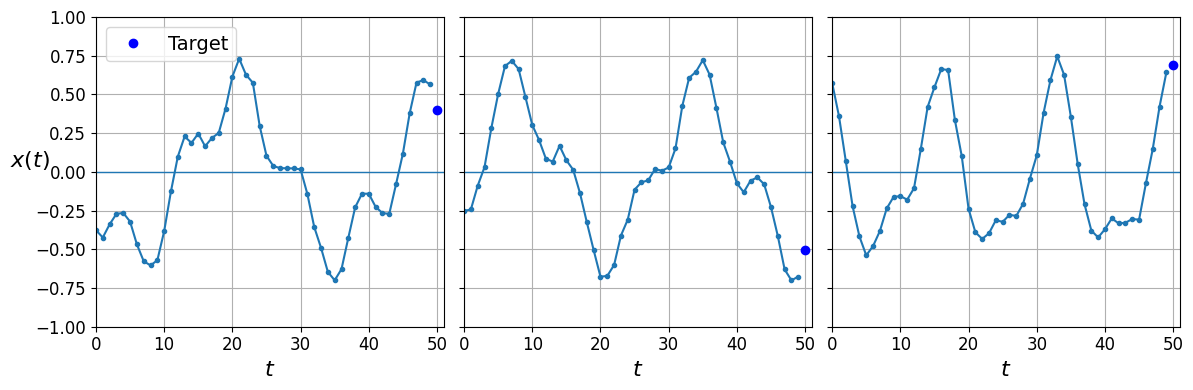

In [5]:
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$", legend=True):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bo", label="Target")
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "rx", markersize=10, label="Prediction")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])
    if legend and (y or y_pred):
        plt.legend(fontsize=14, loc="upper left")

fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None),
                legend=(col == 0))
save_fig("time_series_plot")
plt.show()

**Note**: in this notebook, the blue dots represent targets, and red crosses represent predictions. In the book, I first used blue crosses for targets and red dots for predictions, then I reversed this later in the chapter. Sorry if this caused some confusion.

## Computing Some Baselines

Naive predictions (just predict the last observed value):

In [11]:
y_pred = X_valid[:, -1]
mse = keras.losses.MeanSquaredError()
np.mean(mse(y_valid, y_pred).numpy())

np.float32(0.020211367)

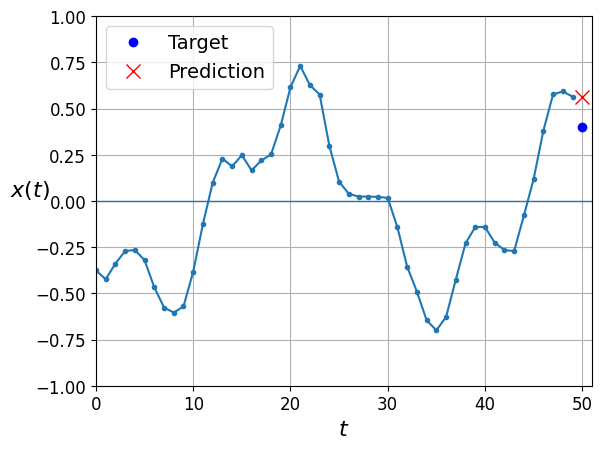

In [12]:
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

Linear predictions:

In [13]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

d:\Source Code\ML\Hands-On Machine Learning with Scikit-Learn, Keras and Tensor Flow (Aurelien Geron)\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0838 - val_loss: 0.0390
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0838 - val_loss: 0.0390
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0278 - val_loss: 0.0192
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0278 - val_loss: 0.0192
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0149 - val_loss: 0.0117
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0149 - val_loss: 0.0117
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0100 - val_loss: 0.0088
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0100 - val_loss: 0.0088
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0080 - val_loss: 0.0074
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0080 - val_loss: 0.0074
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0069 - val_loss: 0.0065
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - 

In [14]:
model.evaluate(X_valid, y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - loss: 0.0034
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - loss: 0.0034


0.0034331551287323236

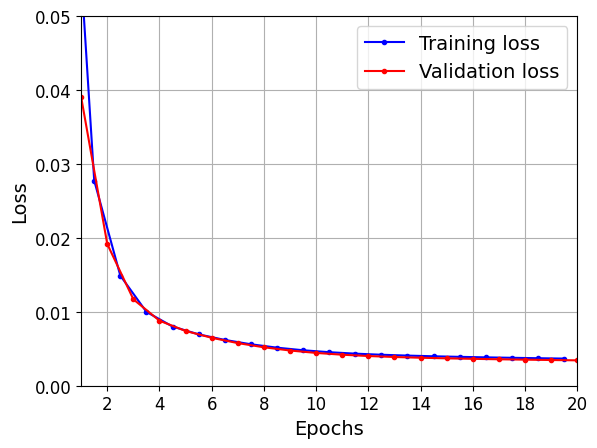

In [15]:
def plot_learning_curves(loss, val_loss):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)

plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step


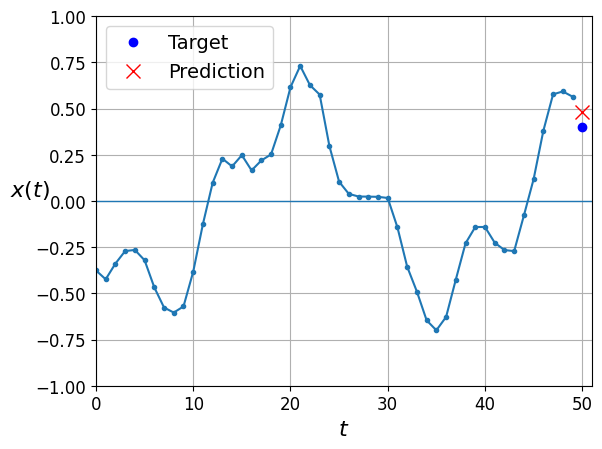

In [16]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

## Using a Simple RNN

In [17]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

optimizer = keras.optimizers.Adam(learning_rate=0.005)
model.compile(loss="mse", optimizer=optimizer)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20


d:\Source Code\ML\Hands-On Machine Learning with Scikit-Learn, Keras and Tensor Flow (Aurelien Geron)\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1227 - val_loss: 0.0344
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1227 - val_loss: 0.0344
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0289 - val_loss: 0.0248
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0289 - val_loss: 0.0248
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0219 - val_loss: 0.0194
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0219 - val_loss: 0.0194
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0179 - val_loss: 0.0162
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0179 - val_loss: 0.0162
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0154 - val_loss: 0.0141
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0154 - val_loss: 0.0141
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0137 - val_loss: 0.0128
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.013

In [18]:
model.evaluate(X_valid, y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0109
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0109


0.010924575850367546

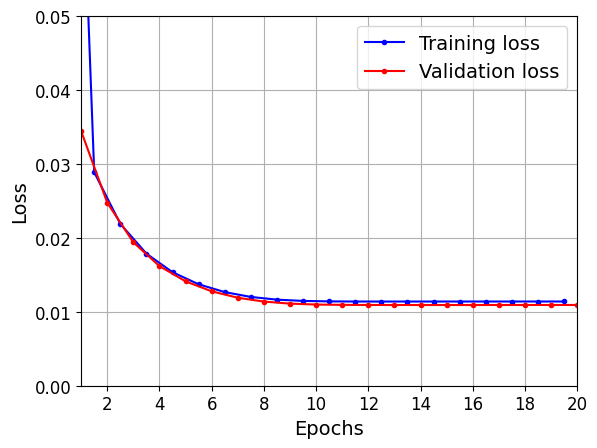

In [19]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


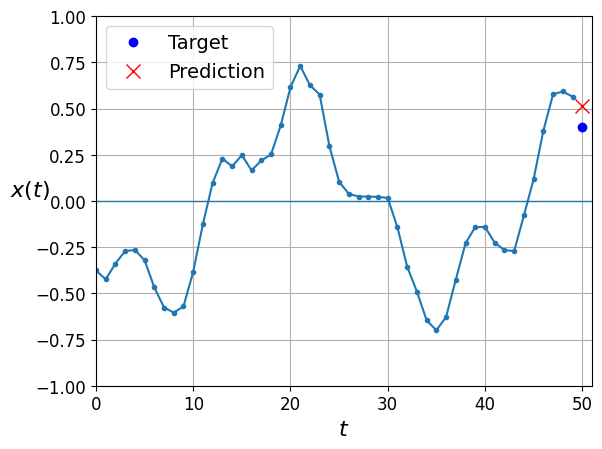

In [20]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

## Deep RNNs

In [21]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0320 - val_loss: 0.0074
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0320 - val_loss: 0.0074
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0057 - val_loss: 0.0044
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0057 - val_loss: 0.0044
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0040 - val_loss: 0.0035
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0040 - val_loss: 0.0035
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0033 - val_loss: 0.0031
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0033 - val_loss: 0.0031
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [22]:
model.evaluate(X_valid, y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028


0.002849410055205226

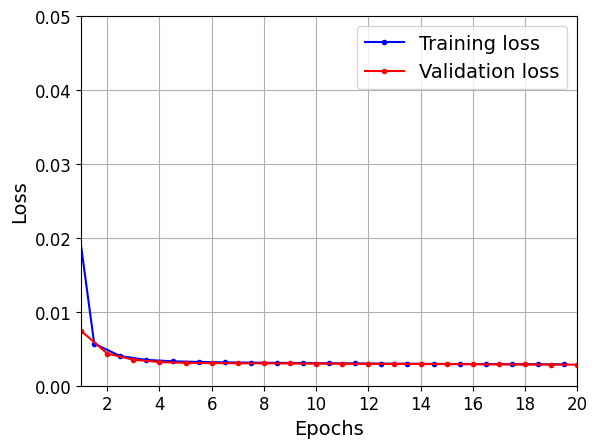

In [23]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


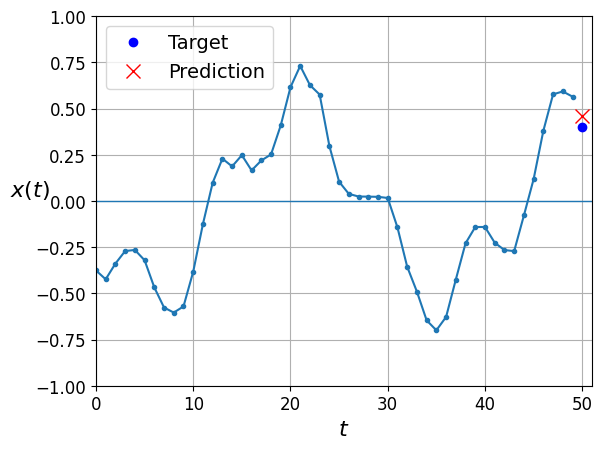

In [24]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

Make the second `SimpleRNN` layer return only the last output:

In [25]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0227 - val_loss: 0.0049
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0227 - val_loss: 0.0049
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0045 - val_loss: 0.0037
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0045 - val_loss: 0.0037
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0035 - val_loss: 0.0031
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0035 - val_loss: 0.0031
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0032 - val_loss: 0.0029
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - 

In [26]:
model.evaluate(X_valid, y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027


0.002674334216862917

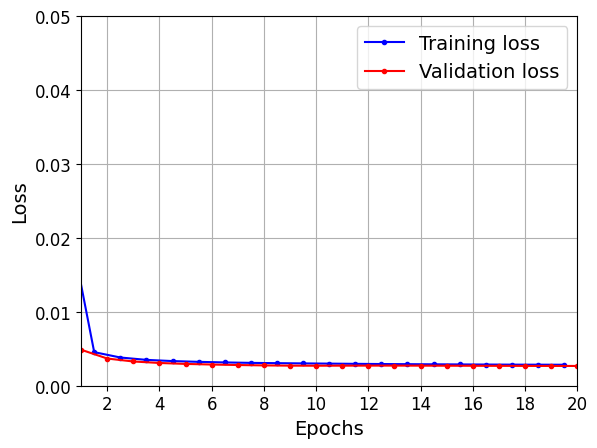

In [27]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


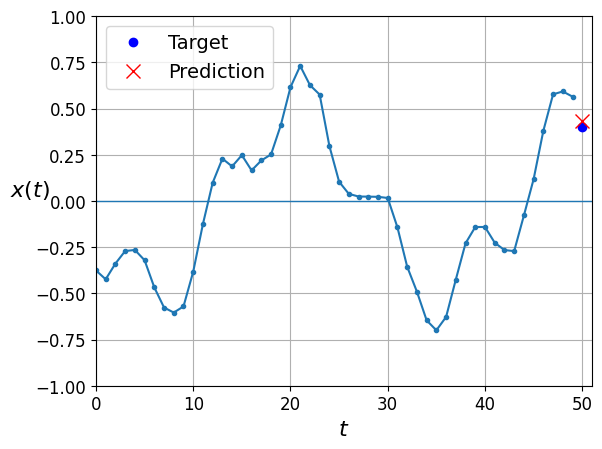

In [28]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

## Forecasting Several Steps Ahead

In [29]:
np.random.seed(43) # not 42, as it would give the first series in the train set

series = generate_time_series(1, n_steps + 10)
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]
X = X_new
for step_ahead in range(10):
    y_pred_one = model.predict(X[:, step_ahead:])[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [30]:
Y_pred.shape

(1, 10, 1)

Saving figure forecast_ahead_plot


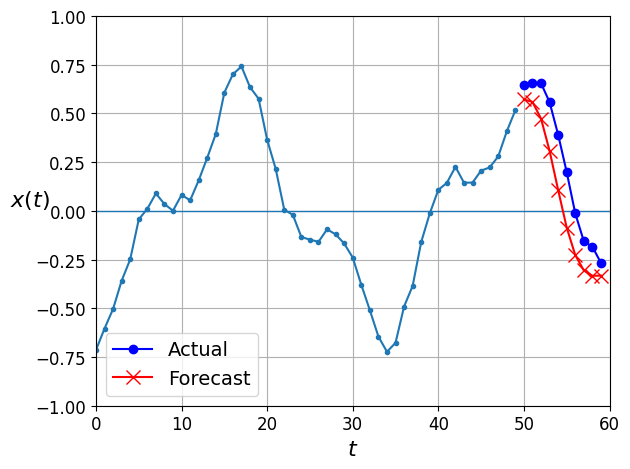

In [31]:
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "bo-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "rx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)

plot_multiple_forecasts(X_new, Y_new, Y_pred)
save_fig("forecast_ahead_plot")
plt.show()

Now let's use this model to predict the next 10 values. We first need to regenerate the sequences with 9 more time steps.

In [32]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10)
X_train, Y_train = series[:7000, :n_steps], series[:7000, -10:, 0]
X_valid, Y_valid = series[7000:9000, :n_steps], series[7000:9000, -10:, 0]
X_test, Y_test = series[9000:, :n_steps], series[9000:, -10:, 0]

Now let's predict the next 10 values one by one:

In [33]:
X = X_valid
for step_ahead in range(10):
    y_pred_one = model.predict(X)[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:, 0]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [34]:
Y_pred.shape

(2000, 10)

In [36]:
mse = keras.losses.MeanSquaredError()
np.mean(mse(Y_valid, Y_pred).numpy())

np.float32(0.027841795)

Let's compare this performance with some baselines: naive predictions and a simple linear model:

In [38]:
Y_naive_pred = np.tile(X_valid[:, -1], 10) # take the last time step value, and repeat it 10 times
mse = keras.losses.MeanSquaredError()
np.mean(mse(Y_valid, Y_naive_pred).numpy())

np.float32(0.25697407)

In [39]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(10)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1264 - val_loss: 0.0596
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1264 - val_loss: 0.0596
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0486 - val_loss: 0.0419
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0486 - val_loss: 0.0419
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0379 - val_loss: 0.0352
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0379 - val_loss: 0.0352
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0328 - val_loss: 0.0312
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0328 - val_loss: 0.0312
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0295 - val_loss: 0.0284
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0295 - val_loss: 0.0284
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0272 - val_loss: 0.0263
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - 

Now let's create an RNN that predicts all 10 next values at once:

In [40]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0753 - val_loss: 0.0383
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0753 - val_loss: 0.0383
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0316 - val_loss: 0.0229
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0316 - val_loss: 0.0229
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0210 - val_loss: 0.0166
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0210 - val_loss: 0.0166
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0165 - val_loss: 0.0135
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0165 - val_loss: 0.0135
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0143 - val_loss: 0.0121
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0143 - val_loss: 0.0121
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0129 - val_loss: 0.0115
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - 

In [41]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, -10:, :]
Y_pred = model.predict(X_new)[..., np.newaxis]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


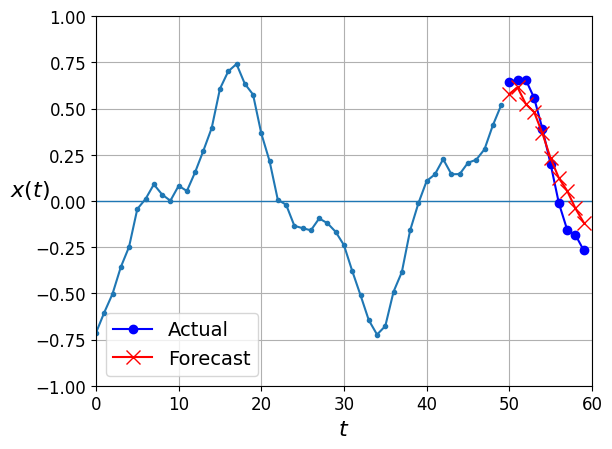

In [42]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

Now let's create an RNN that predicts the next 10 steps at each time step. That is, instead of just forecasting time steps 50 to 59 based on time steps 0 to 49, it will forecast time steps 1 to 10 at time step 0, then time steps 2 to 11 at time step 1, and so on, and finally it will forecast time steps 50 to 59 at the last time step. Notice that the model is causal: when it makes predictions at any time step, it can only see past time steps.

In [43]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10)
X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test = series[9000:, :n_steps]
Y = np.empty((10000, n_steps, 10))
for step_ahead in range(1, 10 + 1):
    Y[..., step_ahead - 1] = series[..., step_ahead:step_ahead + n_steps, 0]
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

In [44]:
X_train.shape, Y_train.shape

((7000, 50, 1), (7000, 50, 10))

In [46]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

def last_time_step_mse(Y_true, Y_pred):
    return tf.reduce_mean(tf.square(Y_true[:, -1] - Y_pred[:, -1]), axis=-1)

model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.01), metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - last_time_step_mse: 0.0355 - loss: 0.0474 - val_last_time_step_mse: 0.0230 - val_loss: 0.0369
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - last_time_step_mse: 0.0355 - loss: 0.0474 - val_last_time_step_mse: 0.0230 - val_loss: 0.0369
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - last_time_step_mse: 0.0221 - loss: 0.0348 - val_last_time_step_mse: 0.0176 - val_loss: 0.0302
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - last_time_step_mse: 0.0221 - loss: 0.0348 - val_last_time_step_mse: 0.0176 - val_loss: 0.0302
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - last_time_step_mse: 0.0177 - loss: 0.0301 - val_last_time_step_mse: 0.0146 - val_loss: 0.0278
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - last_time_step_mse: 0.0177 - loss: 0.0301 - val_last_time_step_mse: 0.0146 - val_loss: 0.0278
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - last_time_step_mse: 0.0162 - loss: 0.0281 - val_last_tim

In [47]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step


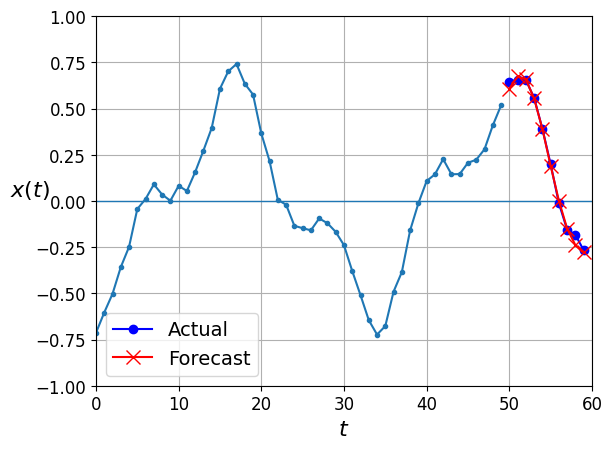

In [48]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

# Deep RNN with Batch Norm

In [49]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.BatchNormalization(),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.BatchNormalization(),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - last_time_step_mse: 0.2164 - loss: 0.2291 - val_last_time_step_mse: 0.0800 - val_loss: 0.0842
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - last_time_step_mse: 0.2164 - loss: 0.2291 - val_last_time_step_mse: 0.0800 - val_loss: 0.0842
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - last_time_step_mse: 0.0479 - loss: 0.0573 - val_last_time_step_mse: 0.0469 - val_loss: 0.0547
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - last_time_step_mse: 0.0479 - loss: 0.0573 - val_last_time_step_mse: 0.0469 - val_loss: 0.0547
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - last_time_step_mse: 0.0404 - loss: 0.0495 - val_last_time_step_mse: 0.0387 - val_loss: 0.0482
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - last_time_step_mse: 0.0404 - loss: 0.0495 - val_last_time_step_mse: 0.0387 - val_loss: 0.0482
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - last_time_step_mse: 0.0370 - loss: 0.0462 - val_las

# Deep RNNs with Layer Norm

In [50]:
from tensorflow.keras.layers import LayerNormalization

In [55]:
class LNSimpleRNNCell(keras.layers.Layer):
    def __init__(self, units, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.state_size = units
        self.output_size = units
        self.units = units
        self.simple_rnn_cell = keras.layers.SimpleRNNCell(units, activation=None)
        self.layer_norm = LayerNormalization()
        self.activation = keras.activations.get(activation)
    
    def build(self, input_shape):
        self.simple_rnn_cell.build(input_shape)
        super().build(input_shape)
    
    def get_initial_state(self, batch_size=None, dtype=None):
        if dtype is None:
            dtype = tf.float32
        return [tf.zeros([batch_size, self.state_size], dtype=dtype)]
    
    def call(self, inputs, states):
        outputs, new_states = self.simple_rnn_cell(inputs, states)
        norm_outputs = self.activation(self.layer_norm(outputs))
        return norm_outputs, [norm_outputs]

In [56]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.RNN(LNSimpleRNNCell(20), return_sequences=True,
                     input_shape=[None, 1]),
    keras.layers.RNN(LNSimpleRNNCell(20), return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - last_time_step_mse: 0.1255 - loss: 0.1399 - val_last_time_step_mse: 0.0517 - val_loss: 0.0652
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - last_time_step_mse: 0.1255 - loss: 0.1399 - val_last_time_step_mse: 0.0517 - val_loss: 0.0652
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - last_time_step_mse: 0.0466 - loss: 0.0584 - val_last_time_step_mse: 0.0409 - val_loss: 0.0531
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - last_time_step_mse: 0.0466 - loss: 0.0584 - val_last_time_step_mse: 0.0409 - val_loss: 0.0531
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - last_time_step_mse: 0.0390 - loss: 0.0500 - val_last_time_step_mse: 0.0351 - val_loss: 0.0470
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - last_time_step_mse: 0.0390 - loss: 0.0500 - val_last_time_step_mse: 0.0351 - val_loss: 0.0470
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - last_time_step_mse: 0.0338 - loss: 0.0442 - val_las

# Creating a Custom RNN Class

In [61]:
class MyRNN(keras.layers.Layer):
    def __init__(self, cell, return_sequences=False, **kwargs):
        super().__init__(**kwargs)
        self.cell = cell
        self.return_sequences = return_sequences
    
    def get_initial_state(self, inputs):
        batch_size = tf.shape(inputs)[0]
        dtype = inputs.dtype
        if hasattr(self.cell, 'get_initial_state'):
            return self.cell.get_initial_state(batch_size=batch_size, dtype=dtype)
        return [tf.zeros([batch_size, self.cell.state_size], dtype=dtype)]
    
    @tf.function
    def call(self, inputs):
        states = self.get_initial_state(inputs)
        shape = tf.shape(inputs)
        batch_size = shape[0]
        n_steps = shape[1]
        sequences = tf.TensorArray(
            inputs.dtype, size=(n_steps if self.return_sequences else 0))
        outputs = tf.zeros(shape=[batch_size, self.cell.output_size], dtype=inputs.dtype)
        for step in tf.range(n_steps):
            outputs, states = self.cell(inputs[:, step], states)
            if self.return_sequences:
                sequences = sequences.write(step, outputs)
        if self.return_sequences:
            return tf.transpose(sequences.stack(), [1, 0, 2])
        else:
            return outputs
    
    def compute_output_shape(self, input_shape):
        if self.return_sequences:
            return (input_shape[0], input_shape[1], self.cell.output_size)
        else:
            return (input_shape[0], self.cell.output_size)

In [62]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    MyRNN(LNSimpleRNNCell(20), return_sequences=True,
          input_shape=[None, 1]),
    MyRNN(LNSimpleRNNCell(20), return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

C:\Users\nakir\AppData\Local\Temp\ipykernel_8128\2205070223.py:3: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20


d:\Source Code\ML\Hands-On Machine Learning with Scikit-Learn, Keras and Tensor Flow (Aurelien Geron)\.venv\Lib\site-packages\keras\src\optimizers\base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['sequential_14/my_rnn_4/ln_simple_rnn_cell_10/simple_rnn_cell_10/kernel', 'sequential_14/my_rnn_4/ln_simple_rnn_cell_10/simple_rnn_cell_10/recurrent_kernel', 'sequential_14/my_rnn_4/ln_simple_rnn_cell_10/simple_rnn_cell_10/bias', 'sequential_14/my_rnn_4/ln_simple_rnn_cell_10/layer_normalization_10/gamma', 'sequential_14/my_rnn_4/ln_simple_rnn_cell_10/layer_normalization_10/beta', 'sequential_14/my_rnn_5/ln_simple_rnn_cell_11/simple_rnn_cell_11/kernel', 'sequential_14/my_rnn_5/ln_simple_rnn_cell_11/simple_rnn_cell_11/recurrent_kernel', 'sequential_14/my_rnn_5/ln_simple_rnn_cell_11/simple_rnn_cell_11/bias', 'sequential_14/my_rnn_5/ln_simple_rnn_cell_11/layer_normalization_11/gamma', 'sequential_14/my_rnn_5/ln_simple_rnn_cell_11/layer_normalization_11/beta'] when minimizi

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - last_time_step_mse: 0.3551 - loss: 0.3373 - val_last_time_step_mse: 0.1809 - val_loss: 0.1694
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - last_time_step_mse: 0.3551 - loss: 0.3373 - val_last_time_step_mse: 0.1809 - val_loss: 0.1694
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - last_time_step_mse: 0.1309 - loss: 0.1291 - val_last_time_step_mse: 0.1048 - val_loss: 0.1060
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - last_time_step_mse: 0.1309 - loss: 0.1291 - val_last_time_step_mse: 0.1048 - val_loss: 0.1060
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - last_time_step_mse: 0.0939 - loss: 0.0965 - val_last_time_step_mse: 0.0871 - val_loss: 0.0903
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - last_time_step_mse: 0.0939 - loss: 0.0965 - val_last_time_step_mse: 0.0871 - val_loss: 0.0903
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - last_time_step_mse: 0.0832 - loss: 0.0868 - val_last_time_step_mse: 0

# LSTMs

In [63]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - last_time_step_mse: 0.0646 - loss: 0.0788 - val_last_time_step_mse: 0.0363 - val_loss: 0.0541
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - last_time_step_mse: 0.0646 - loss: 0.0788 - val_last_time_step_mse: 0.0363 - val_loss: 0.0541
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - last_time_step_mse: 0.0287 - loss: 0.0465 - val_last_time_step_mse: 0.0184 - val_loss: 0.0402
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - last_time_step_mse: 0.0287 - loss: 0.0465 - val_last_time_step_mse: 0.0184 - val_loss: 0.0402
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - last_time_step_mse: 0.0165 - loss: 0.0366 - val_last_time_step_mse: 0.0137 - val_loss: 0.0343
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - last_time_step_mse: 0.0165 - loss: 0.0366 - val_last_time_step_mse: 0.0137 - val_loss: 0.0343
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - last_time_step_mse: 0.0138 - loss: 0.0329 - val_las

In [64]:
model.evaluate(X_valid, Y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - last_time_step_mse: 0.0091 - loss: 0.0235
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - last_time_step_mse: 0.0091 - loss: 0.0235


[0.02352873608469963, 0.00905371829867363]

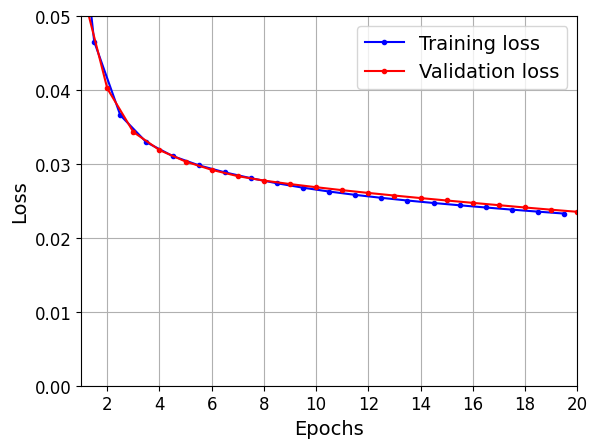

In [65]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

In [66]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step


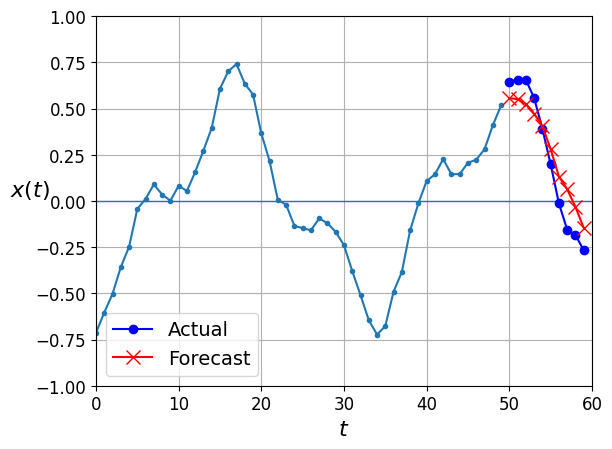

In [67]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

# GRUs

In [68]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.GRU(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - last_time_step_mse: 0.0634 - loss: 0.0713 - val_last_time_step_mse: 0.0421 - val_loss: 0.0529
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - last_time_step_mse: 0.0634 - loss: 0.0713 - val_last_time_step_mse: 0.0421 - val_loss: 0.0529
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - last_time_step_mse: 0.0381 - loss: 0.0484 - val_last_time_step_mse: 0.0339 - val_loss: 0.0451
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - last_time_step_mse: 0.0381 - loss: 0.0484 - val_last_time_step_mse: 0.0339 - val_loss: 0.0451
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - last_time_step_mse: 0.0322 - loss: 0.0431 - val_last_time_step_mse: 0.0293 - val_loss: 0.0411
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - last_time_step_mse: 0.0322 - loss: 0.0431 - val_last_time_step_mse: 0.0293 - val_loss: 0.0411
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - last_time_step_mse: 0.0274 - loss: 0.0390 - val_las

In [69]:
model.evaluate(X_valid, Y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - last_time_step_mse: 0.0090 - loss: 0.0225
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - last_time_step_mse: 0.0090 - loss: 0.0225


[0.022537635639309883, 0.008984607644379139]

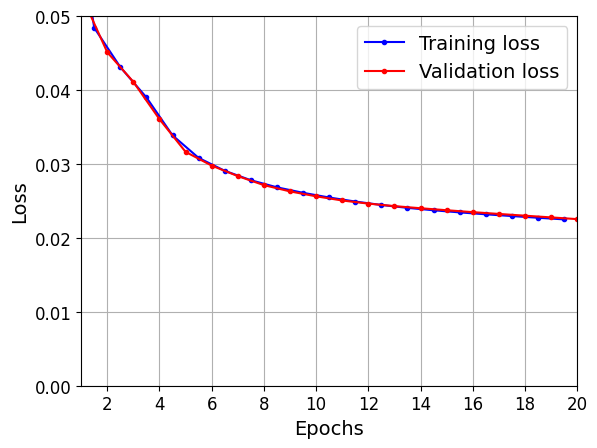

In [70]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

In [71]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step


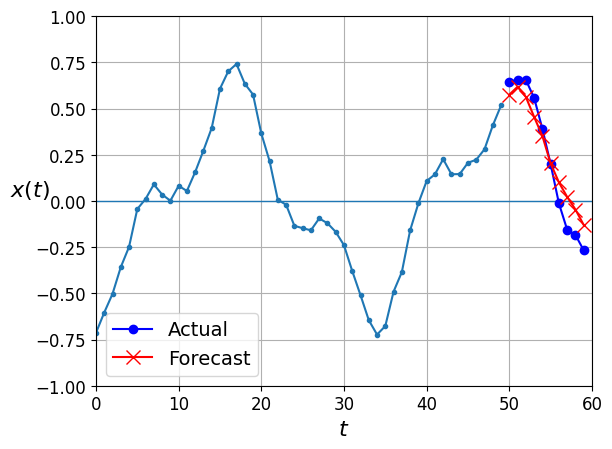

In [72]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

## Using One-Dimensional Convolutional Layers to Process Sequences

```
1D conv layer with kernel size 4, stride 2, VALID padding:

              |-----2-----|     |-----5---...------|     |-----23----|
        |-----1-----|     |-----4-----|   ...      |-----22----|
  |-----0----|      |-----3-----|     |---...|-----21----|
X: 0  1  2  3  4  5  6  7  8  9  10 11 12 ... 42 43 44 45 46 47 48 49
Y: 1  2  3  4  5  6  7  8  9  10 11 12 13 ... 43 44 45 46 47 48 49 50
  /10 11 12 13 14 15 16 17 18 19 20 21 22 ... 52 53 54 55 56 57 58 59

Output:

X:     0/3   2/5   4/7   6/9   8/11 10/13 .../43 42/45 44/47 46/49
Y:     4/13  6/15  8/17 10/19 12/21 14/23 .../53 46/55 48/57 50/59
```

In [73]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Conv1D(filters=20, kernel_size=4, strides=2, padding="valid",
                        input_shape=[None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train[:, 3::2], epochs=20,
                    validation_data=(X_valid, Y_valid[:, 3::2]))

Epoch 1/20


d:\Source Code\ML\Hands-On Machine Learning with Scikit-Learn, Keras and Tensor Flow (Aurelien Geron)\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - last_time_step_mse: 0.0604 - loss: 0.0684 - val_last_time_step_mse: 0.0383 - val_loss: 0.0471
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - last_time_step_mse: 0.0604 - loss: 0.0684 - val_last_time_step_mse: 0.0383 - val_loss: 0.0471
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - last_time_step_mse: 0.0286 - loss: 0.0373 - val_last_time_step_mse: 0.0186 - val_loss: 0.0303
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - last_time_step_mse: 0.0286 - loss: 0.0373 - val_last_time_step_mse: 0.0186 - val_loss: 0.0303
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - last_time_step_mse: 0.0163 - loss: 0.0276 - val_last_time_step_mse: 0.0139 - val_loss: 0.0259
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - last_time_step_mse: 0.0163 - loss: 0.0276 - val_last_time_step_mse: 0.0139 - val_loss: 0.0259
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - last_time_step_mse: 0.0136 - loss: 0.0250 - val_last_time_step

## WaveNet

```
C2  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\.../\ /\ /\ /\ /\ /\
   \  /  \  /  \  /  \  /  \  /  \  /  \       /  \  /  \  /  \
     /    \      /    \      /    \                 /    \
C1  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\  /\ /.../\ /\ /\ /\ /\ /\ /\
X: 0  1  2  3  4  5  6  7  8  9  10 11 12 ... 43 44 45 46 47 48 49
Y: 1  2  3  4  5  6  7  8  9  10 11 12 13 ... 44 45 46 47 48 49 50
  /10 11 12 13 14 15 16 17 18 19 20 21 22 ... 53 54 55 56 57 58 59
```

In [74]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential()
model.add(keras.layers.InputLayer(input_shape=[None, 1]))
for rate in (1, 2, 4, 8) * 2:
    model.add(keras.layers.Conv1D(filters=20, kernel_size=2, padding="causal",
                                  activation="relu", dilation_rate=rate))
model.add(keras.layers.Conv1D(filters=10, kernel_size=1))
model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20


d:\Source Code\ML\Hands-On Machine Learning with Scikit-Learn, Keras and Tensor Flow (Aurelien Geron)\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - last_time_step_mse: 0.0519 - loss: 0.0654 - val_last_time_step_mse: 0.0210 - val_loss: 0.0355
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - last_time_step_mse: 0.0519 - loss: 0.0654 - val_last_time_step_mse: 0.0210 - val_loss: 0.0355
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - last_time_step_mse: 0.0192 - loss: 0.0323 - val_last_time_step_mse: 0.0166 - val_loss: 0.0299
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - last_time_step_mse: 0.0192 - loss: 0.0323 - val_last_time_step_mse: 0.0166 - val_loss: 0.0299
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - last_time_step_mse: 0.0161 - loss: 0.0288 - val_last_time_step_mse: 0.0148 - val_loss: 0.0277
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - last_time_step_mse: 0.0161 - loss: 0.0288 - val_last_time_step_mse: 0.0148 - val_loss: 0.0277
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - last_time_step_mse: 0.0145 - loss: 0.0268 - val_last_time_step_mse: 0

Here is the original WaveNet defined in the paper: it uses Gated Activation Units instead of ReLU and parametrized skip connections, plus it pads with zeros on the left to avoid getting shorter and shorter sequences:

In [75]:
class GatedActivationUnit(keras.layers.Layer):
    def __init__(self, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.activation = keras.activations.get(activation)
    def call(self, inputs):
        n_filters = inputs.shape[-1] // 2
        linear_output = self.activation(inputs[..., :n_filters])
        gate = keras.activations.sigmoid(inputs[..., n_filters:])
        return self.activation(linear_output) * gate

In [76]:
def wavenet_residual_block(inputs, n_filters, dilation_rate):
    z = keras.layers.Conv1D(2 * n_filters, kernel_size=2, padding="causal",
                            dilation_rate=dilation_rate)(inputs)
    z = GatedActivationUnit()(z)
    z = keras.layers.Conv1D(n_filters, kernel_size=1)(z)
    return keras.layers.Add()([z, inputs]), z

In [77]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

n_layers_per_block = 3 # 10 in the paper
n_blocks = 1 # 3 in the paper
n_filters = 32 # 128 in the paper
n_outputs = 10 # 256 in the paper

inputs = keras.layers.Input(shape=[None, 1])
z = keras.layers.Conv1D(n_filters, kernel_size=2, padding="causal")(inputs)
skip_to_last = []
for dilation_rate in [2**i for i in range(n_layers_per_block)] * n_blocks:
    z, skip = wavenet_residual_block(z, n_filters, dilation_rate)
    skip_to_last.append(skip)
z = keras.activations.relu(keras.layers.Add()(skip_to_last))
z = keras.layers.Conv1D(n_filters, kernel_size=1, activation="relu")(z)
Y_proba = keras.layers.Conv1D(n_outputs, kernel_size=1, activation="softmax")(z)

model = keras.models.Model(inputs=[inputs], outputs=[Y_proba])

In [78]:
model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=2,
                    validation_data=(X_valid, Y_valid))

Epoch 1/2
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - last_time_step_mse: 0.1251 - loss: 0.1293 - val_last_time_step_mse: 0.1198 - val_loss: 0.1229
Epoch 2/2
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - last_time_step_mse: 0.1251 - loss: 0.1293 - val_last_time_step_mse: 0.1198 - val_loss: 0.1229
Epoch 2/2
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - last_time_step_mse: 0.1177 - loss: 0.1221 - val_last_time_step_mse: 0.1187 - val_loss: 0.1217
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - last_time_step_mse: 0.1177 - loss: 0.1221 - val_last_time_step_mse: 0.1187 - val_loss: 0.1217


In this chapter we explored the fundamentals of RNNs and used them to process sequences (namely, time series). In the process we also looked at other ways to process sequences, including CNNs. In the next chapter we will use RNNs for Natural Language Processing, and we will learn more about RNNs (bidirectional RNNs, stateful vs stateless RNNs, Encoder–Decoders, and Attention-augmented Encoder-Decoders). We will also look at the Transformer, an Attention-only architecture.